# Qualitative Evaluation Analysis: Declare2PPI vs. PPIPilot

This notebook analyzes a CSV exported from the Google Form used for the qualitative evaluation of **Declare2PPI** against **PPIPilot**.

It is designed for **Google Colab** and supports:
- loading the questionnaire CSV,
- mapping questionnaire sets (A/B and C/D) to the compared approaches,
- descriptive statistics by criterion and process,
- **paired statistical tests** for Likert responses,
- **multiple-testing correction**,
- **effect sizes**,
- **preference analysis**,
- optional reliability analysis (Cronbach's alpha),
- publication-ready tables and plots.

## Recommended interpretation
Since the questionnaire uses **paired Likert-scale ratings (1–5)** from the same respondents, the notebook uses:
- **Wilcoxon signed-rank test** for paired comparisons,
- **Holm correction** for multiple comparisons,
- **rank-biserial correlation** as effect size,
- **binomial tests** for the preference questions.

> Update the configuration cell below to indicate which set corresponds to **Declare2PPI** and which one corresponds to **PPIPilot** for each process.


In [ ]:
# Install dependencies (Colab-safe)
!pip -q install pandas scipy matplotlib openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest, chi2_contingency
from google.colab import files
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Upload or load the CSV

Run the next cell and upload the CSV exported from Google Forms.
If you already mounted Drive or uploaded the file manually, you can set `CSV_PATH` directly.


In [ ]:
# Option A: upload interactively
uploaded = files.upload()
if uploaded:
    CSV_PATH = next(iter(uploaded.keys()))
else:
    CSV_PATH = None

print("CSV_PATH =", CSV_PATH)

Saving Evaluation of Automatically Generated Process Performance Indicators - Evaluation of Automatically Generated Process Performance Indicators.csv to Evaluation of Automatically Generated Process Performance Indicators - Evaluation of Automatically Generated Process Performance Indicators.csv
CSV_PATH = Evaluation of Automatically Generated Process Performance Indicators - Evaluation of Automatically Generated Process Performance Indicators.csv


## 2. Configuration

Set which questionnaire sets correspond to each approach for each process.

- The first process compares **Set A vs Set B**
- The second process compares **Set C vs Set D**

You must map each set to:
- `"Declare2PPI"`
- `"PPIPilot"`

Also provide the process names used in the paper.


In [ ]:
# ---- EDIT THIS CELL BEFORE RUNNING THE ANALYSIS ----

PROCESS_CONFIG = {
    "process_1": {
        "name": "Request for Reimbursement",
        "sets": {"A": "PPIPilot", "B": "Declare2PPI"},
        "preference_column": "Which set of indicators would you prefer to use as a starting point for process performance monitoring?"
    },
    "process_2": {
        "name": "Incident Management",
        "sets": {"C": "Declare2PPI", "D": "PPIPilot"},
        "preference_column": "Which set of indicators would you prefer to use as a starting point for process performance monitoring?.1"
    }
}

CRITERIA = ["Relevance", "Coverage", "Actionability", "Non-Redundancy", "Usefulness", "Understandability"]

# If the CSV was not uploaded interactively, set the path here:
# CSV_PATH = "/content/Evaluation of Automatically Generated Process Performance Indicators.csv"


## 3. Load and inspect the data

In [ ]:
if not CSV_PATH:
    raise ValueError("Please upload the CSV or set CSV_PATH manually in the configuration cell.")

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:")
for c in df.columns:
    print("-", c)

display(df.head(2))

Shape: (22, 38)
Columns:
- Marca temporal
- Current country
- Current position or role
- Main areas of expertise
- Years of Professional Experience
- To what extent are you experienced working with business process management or improvement initiatives?
- To what extent are you experienced defining or using process performance indicators (PPIs or KPIs)?
- To what extent are you familiar with incident management processes (e.g., IT support or service desk processes)?
- To what extent are you familiar with request for reimbursement processes (e.g., employee expense reimbursement)?
- Relevance: To what extent are the PPIs in set A relevant for assessing the performance of the process?
- Relevance: To what extent are the PPIs in set B relevant for assessing the performance of the process?
- Coverage: To what extent do the PPIs in set A collectively cover the main aspects of the process performance? 
- Coverage: To what extent do the PPIs in set B collectively cover the main aspects of the 

,Marca temporal,Current country,Current position or role,Main areas of expertise,Years of Professional Experience,To what extent are you experienced working with business process management or improvement initiatives?,To what extent are you experienced defining or using process performance indicators (PPIs or KPIs)?,"To what extent are you familiar with incident management processes (e.g., IT support or service desk processes)?","To what extent are you familiar with request for reimbursement processes (e.g., employee expense reimbursement)?",Relevance: To what extent are the PPIs in set A relevant for assessing the performance of the process?,...,Actionability: To what extent do the PPIs in set D provide insights that could support decision-making or process improvement?,Non-Redundancy: To what extent do the PPIs in set C avoid unnecessary repetition or overlap?,Non-Redundancy: To what extent do the PPIs in set D avoid unnecessary repetition or overlap?,Usefulness: To what extent would the PPIs in set C be useful for monitoring and improving the process?,Usefulness: To what extent would the PPIs in set D be useful for monitoring and improving the process?,Understandability: To what extent do you find the PPIs in set C understandable?,Understandability: To what extent do you find the PPIs in set D understandable?,Which set of indicators would you prefer to use as a starting point for process performance monitoring?.1,Please briefly explain your choice in previous question.1,"Do you have any comments, suggestions, or observations regarding the PPIs presented in this questionnaire?"
0,2026/03/16 11:22:59 p. m. CET,Italy,Associate Professor,Smart environments,More than 10 years,3,2,4,5,4,...,4,4,4,3,4,5,5,Set D,Also in this case the analysis of response tim...,NaN
1,2026/03/16 11:33:18 p. m. CET,Italy,master’s student,Process mining,0-1 years,4,3,3,2,3,...,4,3,2,4,4,5,4,Set D,NaN,NaN


## 4. Helper functions

In [ ]:
def find_rating_column(df_columns, criterion, set_letter):
    # Matches columns like:
    # "Relevance: To what extent are the PPIs in set A relevant ..."
    prefix = f"{criterion}:"
    candidates = [c for c in df_columns if c.startswith(prefix) and f"set {set_letter}" in c]
    if len(candidates) == 1:
        return candidates[0]
    if len(candidates) == 0:
        raise KeyError(f"No column found for criterion='{criterion}', set='{set_letter}'")
    # If there are multiple, keep the first exact-ish match
    return candidates[0]

def coerce_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def rank_biserial_from_wilcoxon(x, y):
    # Based on paired differences:
    d = pd.Series(x) - pd.Series(y)
    d = d.replace(0, np.nan).dropna()
    n = len(d)
    if n == 0:
        return np.nan
    abs_ranks = d.abs().rank(method="average")
    w_pos = abs_ranks[d > 0].sum()
    w_neg = abs_ranks[d < 0].sum()
    total = abs_ranks.sum()
    return (w_pos - w_neg) / total if total != 0 else np.nan

def holm_correction(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m, dtype=float)
    prev = 0
    for i, idx in enumerate(order):
        adj = (m - i) * pvals[idx]
        adj = max(adj, prev)
        adjusted[idx] = min(adj, 1.0)
        prev = adjusted[idx]
    return adjusted

def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    if k < 2 or len(df_items) < 2:
        return np.nan
    item_vars = df_items.var(axis=0, ddof=1)
    total_var = df_items.sum(axis=1).var(ddof=1)
    if total_var == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_vars.sum() / total_var)

def prepare_process_frame(df, process_key):
    cfg = PROCESS_CONFIG[process_key]
    set_letters = list(cfg["sets"].keys())
    rows = []
    for criterion in CRITERIA:
        for set_letter in set_letters:
            col = find_rating_column(df.columns, criterion, set_letter)
            tmp = pd.DataFrame({
                "respondent": np.arange(len(df)),
                "criterion": criterion,
                "set_letter": set_letter,
                "approach": cfg["sets"][set_letter],
                "score": coerce_numeric(df[col]),
                "process_key": process_key,
                "process_name": cfg["name"],
            })
            rows.append(tmp)
    out = pd.concat(rows, ignore_index=True)
    return out

def paired_test_for_process(df, process_key):
    cfg = PROCESS_CONFIG[process_key]
    # inverse mapping to get letters by approach
    declare_letter = [k for k,v in cfg["sets"].items() if v == "Declare2PPI"][0]
    baseline_letter = [k for k,v in cfg["sets"].items() if v == "PPIPilot"][0]

    results = []
    pvals = []
    for criterion in CRITERIA:
        col_decl = find_rating_column(df.columns, criterion, declare_letter)
        col_base = find_rating_column(df.columns, criterion, baseline_letter)
        pair = pd.DataFrame({
            "declare2ppi": coerce_numeric(df[col_decl]),
            "ppipilot": coerce_numeric(df[col_base])
        }).dropna()

        n = len(pair)
        if n == 0:
            stat = p = rbc = np.nan
            med_decl = med_base = mean_decl = mean_base = np.nan
        else:
            # two-sided paired Wilcoxon
            try:
                stat, p = wilcoxon(pair["declare2ppi"], pair["ppipilot"], zero_method="wilcox", alternative="two-sided", method="auto")
            except ValueError:
                stat, p = np.nan, np.nan
            rbc = rank_biserial_from_wilcoxon(pair["declare2ppi"], pair["ppipilot"])
            med_decl = pair["declare2ppi"].median()
            med_base = pair["ppipilot"].median()
            mean_decl = pair["declare2ppi"].mean()
            mean_base = pair["ppipilot"].mean()

        pvals.append(p)
        results.append({
            "process": cfg["name"],
            "criterion": criterion,
            "n_pairs": n,
            "mean_declare2ppi": mean_decl,
            "mean_ppipilot": mean_base,
            "median_declare2ppi": med_decl,
            "median_ppipilot": med_base,
            "wilcoxon_W": stat,
            "p_value": p,
            "rank_biserial": rbc,
            "better_mean": "Declare2PPI" if pd.notna(mean_decl) and pd.notna(mean_base) and mean_decl > mean_base else ("PPIPilot" if pd.notna(mean_decl) and pd.notna(mean_base) and mean_base > mean_decl else "Tie")
        })
    out = pd.DataFrame(results)
    out["p_holm"] = holm_correction(out["p_value"].fillna(1.0).values)
    return out

def overall_score_test(df, process_key):
    cfg = PROCESS_CONFIG[process_key]
    declare_letter = [k for k,v in cfg["sets"].items() if v == "Declare2PPI"][0]
    baseline_letter = [k for k,v in cfg["sets"].items() if v == "PPIPilot"][0]

    decl_cols = [find_rating_column(df.columns, c, declare_letter) for c in CRITERIA]
    base_cols = [find_rating_column(df.columns, c, baseline_letter) for c in CRITERIA]

    pair = pd.DataFrame({
        "declare2ppi": df[decl_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1),
        "ppipilot": df[base_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1),
    }).dropna()

    stat, p = wilcoxon(pair["declare2ppi"], pair["ppipilot"], zero_method="wilcox", alternative="two-sided", method="auto")
    rbc = rank_biserial_from_wilcoxon(pair["declare2ppi"], pair["ppipilot"])
    return pd.DataFrame([{
        "process": cfg["name"],
        "n_pairs": len(pair),
        "mean_declare2ppi": pair["declare2ppi"].mean(),
        "mean_ppipilot": pair["ppipilot"].mean(),
        "median_declare2ppi": pair["declare2ppi"].median(),
        "median_ppipilot": pair["ppipilot"].median(),
        "wilcoxon_W": stat,
        "p_value": p,
        "rank_biserial": rbc
    }])

def preference_analysis(df, process_key):
    cfg = PROCESS_CONFIG[process_key]
    pref_col = cfg["preference_column"]
    prefs = df[pref_col].dropna().astype(str).str.strip()
    counts = prefs.value_counts()
    set_to_approach = cfg["sets"]
    mapped = counts.rename(index=lambda x: set_to_approach.get(x.replace("Set ", "").strip(), x))
    mapped = mapped.groupby(level=0).sum()
    n = mapped.sum()
    # binomial test only if two approaches present
    declare_n = int(mapped.get("Declare2PPI", 0))
    ppilot_n = int(mapped.get("PPIPilot", 0))
    p = np.nan
    if declare_n + ppilot_n > 0:
        p = binomtest(declare_n, n=declare_n + ppilot_n, p=0.5, alternative="two-sided").pvalue
    return pd.DataFrame([{
        "process": cfg["name"],
        "n_preferences": int(declare_n + ppilot_n),
        "Declare2PPI_pref": declare_n,
        "PPIPilot_pref": ppilot_n,
        "Declare2PPI_pref_rate": declare_n / (declare_n + ppilot_n) if (declare_n + ppilot_n) else np.nan,
        "binom_p_value": p
    }])

def reliability_analysis(df, process_key):
    cfg = PROCESS_CONFIG[process_key]
    rows = []
    for approach in ["Declare2PPI", "PPIPilot"]:
        set_letter = [k for k,v in cfg["sets"].items() if v == approach][0]
        cols = [find_rating_column(df.columns, c, set_letter) for c in CRITERIA]
        items = df[cols].apply(pd.to_numeric, errors="coerce")
        alpha = cronbach_alpha(items)
        rows.append({"process": cfg["name"], "approach": approach, "cronbach_alpha": alpha, "n_rows": len(items.dropna())})
    return pd.DataFrame(rows)

def summarize_respondents(df):
    cols = [
        "Current country",
        "Current position or role",
        "Main areas of expertise",
        "Years of Professional Experience",
        "To what extent are you experienced working with business process management or improvement initiatives?",
        "To what extent are you experienced defining or using process performance indicators (PPIs or KPIs)?"
    ]
    available = [c for c in cols if c in df.columns]
    return {c: df[c].value_counts(dropna=False).to_dict() for c in available}


## 5. Descriptive statistics

In [ ]:
long_df = pd.concat(
    [prepare_process_frame(df, "process_1"), prepare_process_frame(df, "process_2")],
    ignore_index=True
)

desc = (
    long_df.groupby(["process_name", "approach", "criterion"])["score"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
    .sort_values(["process_name", "criterion", "approach"])
)

display(Markdown("### Descriptive statistics by process, approach, and criterion"))
display(desc)

display(Markdown("### Respondent profile summary"))
resp_summary = summarize_respondents(df)
for k, v in resp_summary.items():
    print(f"\n{k}")
    print(pd.Series(v))

### Descriptive statistics by process, approach, and criterion

,process_name,approach,criterion,count,mean,std,median
0,Incident Management,Declare2PPI,Actionability,22,3.727273,0.827032,4.0
6,Incident Management,PPIPilot,Actionability,22,3.363636,1.002162,3.5
1,Incident Management,Declare2PPI,Coverage,22,4.045455,0.575473,4.0
7,Incident Management,PPIPilot,Coverage,22,3.272727,0.984732,3.0
2,Incident Management,Declare2PPI,Non-Redundancy,22,3.863636,0.888844,4.0
8,Incident Management,PPIPilot,Non-Redundancy,22,2.863636,1.082126,2.5
3,Incident Management,Declare2PPI,Relevance,22,3.909091,1.019294,4.0
9,Incident Management,PPIPilot,Relevance,22,3.590909,0.959121,3.0
4,Incident Management,Declare2PPI,Understandability,22,3.909091,0.921132,4.0
10,Incident Management,PPIPilot,Understandability,22,3.772727,1.066004,4.0


### Respondent profile summary


Current country
Italy          9
Spain          9
Netherlands    2
Switzerland    2
dtype: int64

Current position or role
PhD Student                                                      9
master’s student                                                 2
Assistant Professor                                              2
Associate Professor                                              1
Phd Student in Engineering in Computer Science                   1
Researcher / PhD Candidate                                       1
Jefe de servicio de Informática del Servicio Andaluz de Salud    1
Chief Information Officer                                        1
University professor                                             1
CIO                                                              1
Manager                                                          1
Business analyst/ service manager                                1
dtype: int64

Main areas of expertise
Process mining                    

## 6. Paired statistical tests by criterion

For each process and each criterion:
- **H0**: median paired difference between Declare2PPI and PPIPilot is zero
- **Test**: Wilcoxon signed-rank
- **Correction**: Holm correction within each process
- **Effect size**: rank-biserial correlation

Interpretation of rank-biserial correlation (rough rule of thumb):
- `|r| < 0.10`: negligible
- `0.10–0.30`: small
- `0.30–0.50`: medium
- `> 0.50`: large


In [ ]:
rq_results = []
for pk in PROCESS_CONFIG.keys():
    rq_results.append(paired_test_for_process(df, pk))
wilcoxon_results = pd.concat(rq_results, ignore_index=True)

display(wilcoxon_results)

# Save
wilcoxon_results.to_csv("wilcoxon_by_criterion.csv", index=False)
print("Saved: wilcoxon_by_criterion.csv")

,process,criterion,n_pairs,mean_declare2ppi,mean_ppipilot,median_declare2ppi,median_ppipilot,wilcoxon_W,p_value,rank_biserial,better_mean,p_holm
0,Request for Reimbursement,Relevance,22,4.045455,3.409091,4.0,3.0,42.0,0.027054,0.557895,Declare2PPI,0.102552
1,Request for Reimbursement,Coverage,22,4.136364,3.363636,4.0,3.0,39.5,0.010673,0.623810,Declare2PPI,0.064040
2,Request for Reimbursement,Actionability,22,4.090909,3.227273,4.0,3.5,34.5,0.022174,0.596491,Declare2PPI,0.102552
3,Request for Reimbursement,Non-Redundancy,22,3.681818,2.863636,4.0,3.0,26.0,0.026645,0.617647,Declare2PPI,0.102552
4,Request for Reimbursement,Usefulness,22,3.954545,3.136364,4.0,3.0,44.5,0.020510,0.576190,Declare2PPI,0.102552
5,Request for Reimbursement,Understandability,22,3.363636,3.954545,4.0,4.0,47.0,0.082068,-0.450292,PPIPilot,0.102552
6,Incident Management,Relevance,22,3.909091,3.590909,4.0,3.0,74.0,0.388035,0.221053,Declare2PPI,0.776071
7,Incident Management,Coverage,22,4.045455,3.272727,4.0,3.0,20.0,0.011001,0.705882,Declare2PPI,0.066008
8,Incident Management,Actionability,22,3.727273,3.363636,4.0,3.5,37.0,0.170802,0.383333,Declare2PPI,0.512407
9,Incident Management,Non-Redundancy,22,3.863636,2.863636,4.0,2.5,20.5,0.012013,0.698529,Declare2PPI,0.066008


Saved: wilcoxon_by_criterion.csv


## 7. Overall score comparison (mean of the six criteria)

This provides a compact paired comparison per process over the average Likert score.


In [ ]:
overall = pd.concat(
    [overall_score_test(df, "process_1"), overall_score_test(df, "process_2")],
    ignore_index=True
)
display(overall)

overall.to_csv("wilcoxon_overall_score.csv", index=False)
print("Saved: wilcoxon_overall_score.csv")

,process,n_pairs,mean_declare2ppi,mean_ppipilot,median_declare2ppi,median_ppipilot,wilcoxon_W,p_value,rank_biserial
0,Request for Reimbursement,22,3.878788,3.325758,4.0,3.166667,56.0,0.022028,0.557312
1,Incident Management,22,3.893939,3.378788,4.0,3.166667,60.0,0.053508,0.480519


Saved: wilcoxon_overall_score.csv


## 8. Preference analysis

The form also asks which set the respondent would prefer as a starting point for process performance monitoring.
We analyze that with a **binomial test** against a 50/50 preference.


In [ ]:
pref = pd.concat(
    [preference_analysis(df, "process_1"), preference_analysis(df, "process_2")],
    ignore_index=True
)
display(pref)

pref.to_csv("preference_analysis.csv", index=False)
print("Saved: preference_analysis.csv")

,process,n_preferences,Declare2PPI_pref,PPIPilot_pref,Declare2PPI_pref_rate,binom_p_value
0,Request for Reimbursement,22,16,6,0.727273,0.052479
1,Incident Management,21,14,7,0.666667,0.189247


Saved: preference_analysis.csv


## 9. Visualization

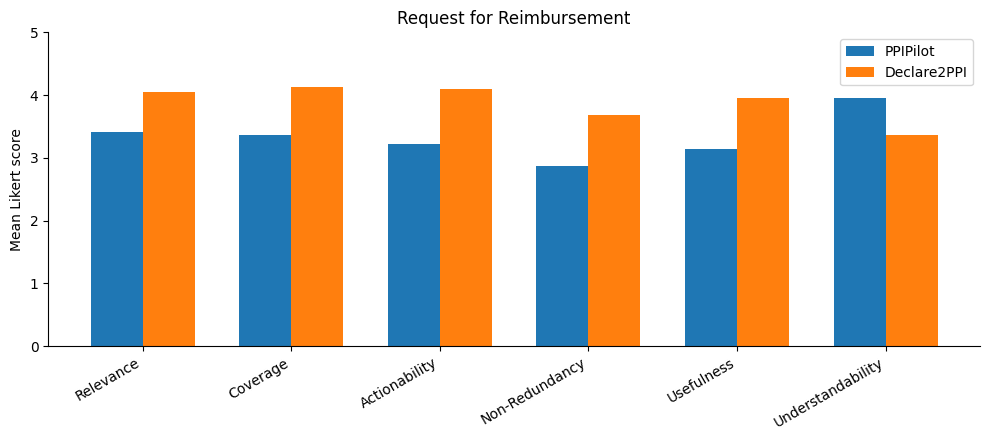

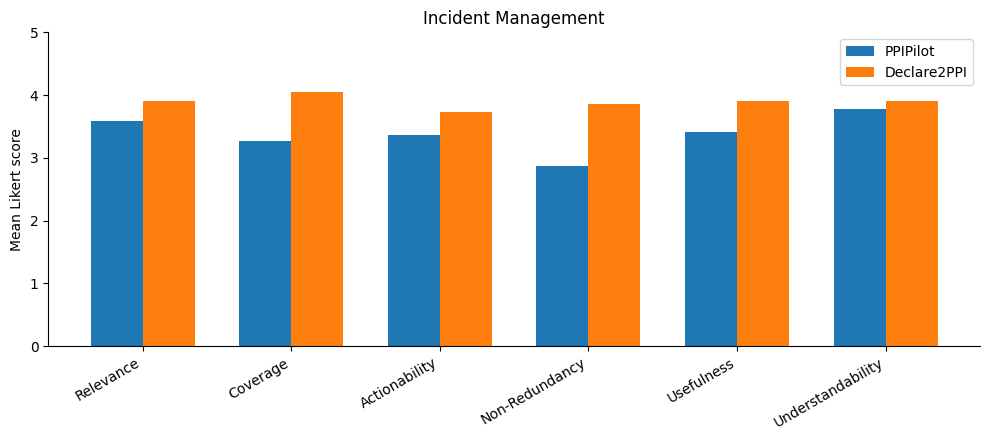

In [ ]:
def plot_means(desc, process_name):
    sub = desc[desc["process_name"] == process_name].copy()
    crits = CRITERIA
    x = np.arange(len(crits))
    width = 0.35

    decl = sub[sub["approach"] == "Declare2PPI"].set_index("criterion").reindex(crits)
    base = sub[sub["approach"] == "PPIPilot"].set_index("criterion").reindex(crits)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(x - width/2, base["mean"], width, label="PPIPilot")
    ax.bar(x + width/2, decl["mean"], width, label="Declare2PPI")
    ax.set_xticks(x)
    ax.set_xticklabels(crits, rotation=30, ha="right")
    ax.set_ylim(0, 5)
    ax.set_ylabel("Mean Likert score")
    ax.set_title(process_name)
    ax.legend()
    plt.tight_layout()
    plt.show()

for pk in PROCESS_CONFIG:
    plot_means(desc, PROCESS_CONFIG[pk]["name"])

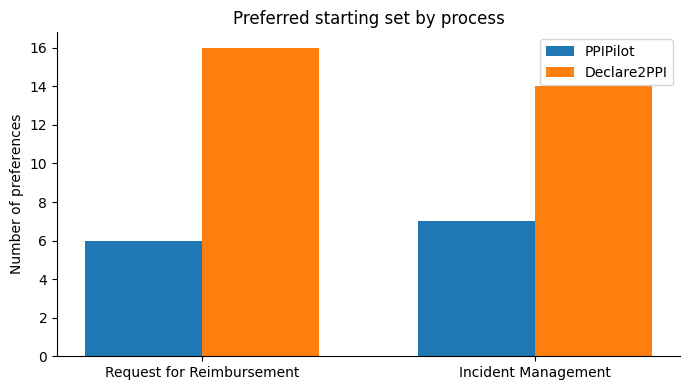

In [ ]:
def plot_preferences(pref_df):
    fig, ax = plt.subplots(figsize=(7, 4))
    x = np.arange(len(pref_df))
    width = 0.35
    ax.bar(x - width/2, pref_df["PPIPilot_pref"], width, label="PPIPilot")
    ax.bar(x + width/2, pref_df["Declare2PPI_pref"], width, label="Declare2PPI")
    ax.set_xticks(x)
    ax.set_xticklabels(pref_df["process"])
    ax.set_ylabel("Number of preferences")
    ax.set_title("Preferred starting set by process")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_preferences(pref)